In [1]:
# Basic imports
import numpy as np
import matplotlib.pyplot as plt
from time import time

# Our microeconomic model of interest
from HARK.models import WealthPortfolioConsumerType

# Some tools from HARK
from HARK.utilities import make_polynomial_params
from HARK.Calibration import (
    Cagetti_income,
    parse_income_spec,
    parse_time_params,
    parse_ssa_life_table,
)
from HARK.rewards import CRRAutility
from HARK.core import multi_thread_commands_fake
from HARK.estimation import minimize_nelder_mead

mystr = lambda x: "{:.4f}".format(x)

In [2]:
# Make a very small extension of RiskyAssetConsumerType that adjusts its pre_solve and post_solve methods
class CustomRiskyAssetConsumerType(WealthPortfolioConsumerType):
    def pre_solve(self):
        WealthPortfolioConsumerType.pre_solve(self)
        if hasattr(self, "ShareCoeffs"):
            self.construct("RiskyShareFixed")

    def post_solve(self):
        if not hasattr(self, "OptValue"):
            return
        del self.ShareCoeffs
        self.ThisValue = self.solution[0].vFuncAdj(1.0)
        self.ValueFac = (self.OptValue / self.ThisValue) ** (-1.0 / (1 - self.CRRA))
        del self.solution

In [3]:
# Define a custom constructor for RiskyShareFixed
def make_logit_polynomial_RiskyShareFixed(ShareCoeffs, FlatShare_t, T_cycle):
    """
    Construct a logit-transformed polynomial life-cycle sequence of risky asset shares.

    Parameters
    ----------
    ShareCoeffs : np.array
        Array of polynomial coefficients for logit-transformed risky asset shares.
    FlatShare_t : int
        Period of the model after which to hold risky share fixed (at that age's share).
    T_cycle : int
        Number of periods in this agent's life-cycle.

    Returns
    -------
    RiskyShareFixed : [float]
        Age-varying list of fixed risky asset shares, i.e. a glidepath.
    """
    n = len(ShareCoeffs)
    coeffs_adj = ShareCoeffs.copy() * 0.01 ** np.arange(n)
    temp = make_polynomial_params(coeffs_adj, T_cycle)
    RiskyShareFixed = 1.0 / (1.0 + np.exp(temp))
    OldAgeShare = RiskyShareFixed[FlatShare_t]
    RiskyShareFixed[FlatShare_t:] = OldAgeShare
    return RiskyShareFixed.tolist()

In [4]:
# Define a custom constructor for AutarkyValue
def calc_autarky_value(PermGroFac, DiscFac, LivPrb, CRRA):
    """
    Calculate the lifetime value of consuming permanent income every period,
    with no income risk.

    Parameters
    ----------
    PermGroFac : [float]
        Permanent income growth factor by age.
    DiscFac : float
        Intertemporal discount factor.
    LivPrb : [float]
        Survival probability by age
    CRRA : float
        Coefficient of relative risk aversion.

    Returns
    -------
    AutarkyValue : float
        Present discounted value of the perfect foresight autarky plan.
    """
    y = np.concatenate((np.array([1.0]), np.cumprod(PermGroFac)))
    u = CRRAutility(y, rho=CRRA)
    weight = DiscFac ** (np.arange(len(LivPrb) + 1))
    weight *= np.concatenate((np.array([1.0]), np.cumprod(LivPrb)))
    wu = weight * u
    AutarkyValue = np.sum(wu)
    return AutarkyValue

In [5]:
# Define a life-cycle calibration using HARK tools
birth_age = 22
death_age = 115

# Build income specifications
college_income = parse_income_spec(
    age_min=birth_age,
    age_max=death_age,
    adjust_infl_to=1992,
    **Cagetti_income["College"],
)

highschool_income = parse_income_spec(
    age_min=birth_age,
    age_max=death_age,
    adjust_infl_to=1992,
    **Cagetti_income["HS"],
)

dropout_income = parse_income_spec(
    age_min=birth_age,
    age_max=death_age,
    adjust_infl_to=1992,
    **Cagetti_income["NoHS"],
)

# Gather them into one list
income_params = [dropout_income, highschool_income, college_income]

# Build survival and time specification
liv_prb = parse_ssa_life_table(
    female=False, cross_sec=True, year=2004, age_min=birth_age, age_max=death_age
)
time_params = parse_time_params(age_birth=birth_age, age_death=death_age)

# Some specific parameters we might be interested in changing
my_params = {
    "AgentCount": 10000,  # number of agents to simulate
    "T_sim": time_params["T_cycle"] + 1,
    "vFuncBool": True,  # construct the value function
    "UnempPrbRet": 0.0,  # Turn off possibility of missing SS benefits
    "WealthShare": 0.2,
    "WealthShift": 0.0,
    "RiskyShareFixed": None,  # just for now
    "FlatShare_t": 95 - birth_age,  # model age at which to hold risky share fixed
}

# We're going to do something a little strange, so these are split off
alt_params = {
    "RiskyShareFixed": [1.0],  # this will be overwritten
    "ShareCoeffs": [0.0],  # this will be overwritten
}

# Put it all together into one dictionary
lifecycle_dict = my_params.copy()
lifecycle_dict["LivPrb"] = liv_prb
lifecycle_dict.update(**time_params)
lifecycle_dict["Rfree"] = lifecycle_dict["T_cycle"] * [1.03]

In [6]:
# Define a function that makes one custom agent type
def make_one_custom_type(educ, beta, rho, weight):
    """
    Make an instance of RiskyAssetConsumerType with a typical life-cycle specification,
    but with age-varying RiskyShareFixed (i.e. a glidepath) and the ability to specify
    it with polynomial coefficients.

    Parameters
    ----------
    educ : int
        Indicator for education: 0 dropout, 1 high school, 2 college.
    beta : float
        Intertemporal discount factor.
    rho : float
        Coefficient of relative risk aversion.
    weight : float
        Relative weight on this type.

    Returns
    -------
    ThisType : RiskyAssetConsumerType
        New instance of RiskyAssetConsumerType with a few special features.
    """
    # Make the type with flexible portfolio share
    temp_dict = {
        "DiscFac": beta,
        "CRRA": rho,
        "weight": weight,
    }
    temp_dict.update(lifecycle_dict)
    temp_dict.update(income_params[educ])
    ThisType = CustomRiskyAssetConsumerType(**temp_dict)

    # Solve the problem with flexible portfolio share and store value
    ThisType.solve()
    ThisType.OptValue = ThisType.solution[0].vFuncAdj(1.0)

    # Now make the agents have a fixed portfolio glidepath
    ThisType.assign_parameters(**alt_params)
    ThisType.constructors["RiskyShareFixed"] = make_logit_polynomial_RiskyShareFixed
    ThisType.construct()
    del ThisType.solution
    # ThisType.del_from_time_inv("RiskyShareFixed")
    # ThisType.add_to_time_vary("RiskyShareFixed")

    return ThisType

In [7]:
# Define a function that makes many types from a list with specifications
def make_type_list(agent_specs):
    """
    Make a list of custom RiskyAssetConsumerTypes with specified attributes.

    Parameters
    ----------
    agent_specs: [[int, float, float, float]]
        List of quadruples, with each element specifying one custom type.
        Order: educ index, beta, rho, weight.

    Returns
    -------
    TypeList : [RiskyAssetConsumerType]
        Constructed list of types based on input data.
    """
    N = len(agent_specs)
    TypeList = []
    for n in range(N):
        TypeList.append(make_one_custom_type(*agent_specs[n]))
    return TypeList

In [8]:
# Define a social welfare-like objective function
def calc_average_value_factor(coeffs, agents):
    """
    Calculate the population average consumption equivalent factor for the glidepath
    characterized by the given population for the provided agents.

    Parameters
    ----------
    coeffs : np.array
        Polynomial coefficients for (logit-transformed) risky share weights.
    agents : [AgentType]
        List of ex ante heterogeneous agent types in the population.

    Returns
    -------
    out : float
        Weighted average of ValueFac across all agent types in the population.
    """
    for agent in agents:
        agent.ShareCoeffs = coeffs
    multi_thread_commands_fake(agents, ["solve"])
    out = np.sum([agent.weight * agent.ValueFac for agent in agents])
    print(coeffs, out)
    return out

In [9]:
MyType = make_one_custom_type(1, 0.96, 5.5, 1337)

In [10]:
t0 = time()
MyType.ShareCoeffs = [-7.0918, 68.0202, -236.7197, 362.2768, -202.7891]
MyType.solve()
t1 = time()
print("That took " + mystr(t1 - t0) + " seconds; result is " + str(MyType.ValueFac))

That took 0.4483 seconds; result is 0.9988110632458239


In [37]:
# Make an arbitrary set of types
agent_data = [
    [0, 0.97, 2.5, 123.0],
    [1, 0.96, 3.7, 435.0],
    [2, 0.95, 4.2, 222.0],
    # [0, 0.92, 3.5, 123.],
    # [1, 0.93, 4.7, 435.],
    # [2, 0.94, 5.2, 222.],
    # [0, 0.99, 5.5, 123.],
    # [1, 0.99, 6.7, 435.],
    # [2, 0.99, 7.2, 222.],
    # [0, 0.90, 1.5, 123.],
    # [1, 0.90, 2.7, 435.],
    # [2, 0.90, 3.2, 222.],
    # [0, 0.95, 8.5, 123.],
    # [1, 0.96, 8.7, 435.],
    # [2, 0.97, 8.2, 222.],
    # [0, 0.96, 6.5, 123.],
    # [1, 0.96, 6.7, 435.],
    # [2, 0.96, 6.2, 222.],
]
AllTypes = make_type_list(agent_data)

In [38]:
# Test the social welfare function
t0 = time()
out = calc_average_value_factor(
    [-2.27288942, 12.45256032, -9.47212421, 0.59790169, -2.35758162], AllTypes
)
t1 = time()
print("That took " + mystr(t1 - t0) + " seconds; result is " + str(out))

[-2.27288942, 12.45256032, -9.47212421, 0.59790169, -2.35758162] 773.5747591735923
That took 1.3344 seconds; result is 773.5747591735923


In [39]:
# Define an objective function with one argument
obj_func = lambda x: -calc_average_value_factor(x, AllTypes)

In [40]:
# Perform an estimation over two parameter glidepath
optimization_result = minimize_nelder_mead(
    obj_func,
    [-2.27288942, 12.45256032, -9.47212421, 0.59790169, -2.35758162],
    verbose=True,
)

[-2.27288942 12.45256032 -9.47212421  0.59790169 -2.35758162] 773.5747591735923
[-2.38653389 12.45256032 -9.47212421  0.59790169 -2.35758162] 774.2643277716977
[-2.27288942 13.07518834 -9.47212421  0.59790169 -2.35758162] 772.6998412398555
[-2.27288942 12.45256032 -9.94573042  0.59790169 -2.35758162] 773.7793830579594
[-2.27288942 12.45256032 -9.47212421  0.62779677 -2.35758162] 773.56982905753
[-2.27288942 12.45256032 -9.47212421  0.59790169 -2.4754607 ] 773.5830301338887
[-2.31834721 11.8299323  -9.66156669  0.60985972 -2.40473325] 774.7491495943804
[-2.3410761  11.20730429 -9.75628794  0.61583874 -2.42830907] 775.6296681522663
[-2.34562188 11.95445791 -9.77523218  0.57518143 -2.43302423] 774.8007807284354
[-2.37471487 11.75521694 -9.89647537  0.5959884  -2.46320128] 775.2450224092219
[ -2.41544504  11.47627959 -10.06621584   0.59522309  -2.34041843] 775.8130229675247
[ -2.48672286  10.98813923 -10.36326166   0.59388379  -2.27289729] 776.6576477083197
[-2.50097842 10.89051115 -9.7596

In [41]:
old_params = [-7.0918, 68.0202, -236.7197, 362.2768, -202.7891]
GP = make_logit_polynomial_RiskyShareFixed(
    [-11.79624881, 61.03450312, -92.37140006, 8.06921861, 47.35055665], 73, 93
)
age_vec = np.arange(birth_age, death_age)

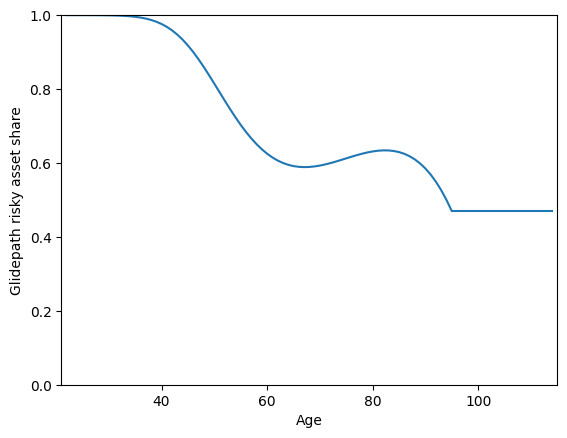

In [42]:
plt.plot(age_vec, GP)
plt.xlim(birth_age - 1, death_age)
plt.ylim(0.0, 1.0)
plt.xlabel("Age")
plt.ylabel("Glidepath risky asset share")
plt.show()

In [ ]:
[agent.ValueFac for agent in AllTypes]